# 1. Imports & Setup

In [18]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# 2.LOAD & SPLIT DATA

In [20]:
df = pd.read_csv('cleaned_diabetes.csv')
X = df.drop(columns=['readmitted'])
y = df['readmitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print(f"Initial Training Data Shape: {X_train.shape}")

Initial Training Data Shape: (81412, 44)


# 3. SCALE & SMOTE

In [22]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
print("Balancing classes with SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

Balancing classes with SMOTE...


# 4. MODEL TRAINING

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=150,    # Increased number of trees
    max_depth=20,        # Allowed trees to grow deeper to find complex patterns
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 
)

print("Training Random Forest Model...")
rf_model.fit(X_train_resampled, y_train_resampled)
predictions = rf_model.predict(X_test_scaled)

Training Random Forest Model...


# 5. RESULTS & VISUALS

In [25]:
accuracy = accuracy_score(y_test, predictions)
print(f"\nOverall Test Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, predictions))


Overall Test Accuracy: 0.5828

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.07      0.11      2285
           1       0.50      0.40      0.44      7117
           2       0.63      0.81      0.70     10952

    accuracy                           0.58     20354
   macro avg       0.49      0.43      0.42     20354
weighted avg       0.55      0.58      0.55     20354



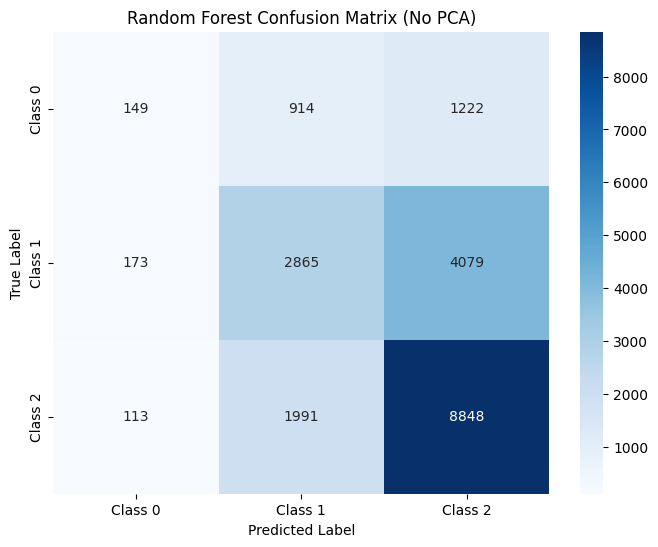

In [26]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'], 
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix (No PCA)')
plt.show()